# 3 — Hybrid search, re-ranking, and grading

The first two notebooks used a single dense top-k. This one adds three retrieval upgrades and ablates them: **BM25 + dense via RRF** (catches literal term-matches dense vectors miss), **cross-encoder reranking** (a model that reads full text against the query, vs dense vectors which are compressed), and **LLM grading** (CRAG-style — drops irrelevant chunks before they pollute the prompt).

| Configuration                   | Retrieval recall | Mean rubric overall | Mean context tokens |
|---------------------------------|-----------------:|--------------------:|--------------------:|
| Dense only (baseline)           | ...              | ...                 | ...                 |
| Hybrid (BM25 + dense, RRF)      | ...              | ...                 | ...                 |
| Hybrid + cross-encoder rerank   | ...              | ...                 | ...                 |
| Hybrid + rerank + LLM grader    | ...              | ...                 | ...                 |

We track context tokens alongside recall because the grader doesn't just reorder, it *drops* — so the synth sees a smaller, cleaner prompt. Plus a multi-model sweep on the grader itself: does the judge model matter?

In [1]:
import os
import time
from dotenv import load_dotenv
import pandas as pd

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY")

from corpus import load_chroma, load_bm25, load_gold_set
from retrievers import (
    HybridRetriever,
    CrossEncoderReranker,
    dense_search,
    bm25_search,
    filter_by_source,
)
from judges import grade_chunk
from llm import get_llm

chroma = load_chroma()
bm25 = load_bm25()
gold = load_gold_set()

print(f"Corpus: {chroma._collection.count()} chunks, BM25 over {len(bm25['documents'])} docs")

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5942.41it/s]


Corpus: 3689 chunks, BM25 over 3689 docs


## A query where dense and sparse disagree

Pick a question with a specific named entity (BM25 will love it) and an abstract concept (dense will love it). Look at the top-5 from each and at the RRF-fused result.

In [2]:
QUERY = "What is BM25 and how does it differ from dense retrieval?"

dense_hits = dense_search(chroma, QUERY, k=5)
sparse_hits = bm25_search(bm25, QUERY, k=5)

hybrid_retriever = HybridRetriever(chroma, bm25, k=5)
fused_hits = hybrid_retriever.search(QUERY)


def show(label, docs):
    print(f"\n--- {label} ---")
    for d in docs:
        src = d.metadata.get("source")
        title = d.metadata.get("title", "?")[:55]
        print(f"  [{src:9}] {title}: {d.page_content[:90]}...")


show("Dense (Chroma + MiniLM)", dense_hits)
show("Sparse (BM25)", sparse_hits)
show("Hybrid (RRF fused)", fused_hits)


--- Dense (Chroma + MiniLM) ---
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

BM25+ is an extension of BM25. BM25+ was develope...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

In information retrieval, Okapi BM25 (BM is an ab...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

== Modifications ==
At the extreme values of the ...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

== The ranking function ==
BM25 is a bag-of-words...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

== External links ==
Robertson, Stephen; Zaragoza...

--- Sparse (BM25) ---
  [wikipedia] Artificial intelligence: [source: wikipedia | title: Artificial intelligence]

David Chalmers identified two proble...
  [wikipedia] Information retrieval: [source: wikipedia | title: Information retrieval]

=== Third Dimension: representational ...
  [wikipedia] Information retrieval: [source: wikipedia | title: Information ret

## Reciprocal Rank Fusion in two lines

For ranks $r_i$ across $m$ rank lists, RRF gives each document score $\sum_i \frac{1}{k + r_i}$ where $k=60$ is the standard constant. It's parameter-light, doesn't need score calibration, and works well when the two retrievers disagree on absolute scores. The fusion logic is in `retrievers.rrf_fuse`.

## Cross-encoder reranking

The reranker reads `(query, full chunk text)` jointly through a transformer and outputs a relevance score. Compared with the bi-encoder embeddings used for retrieval, it's slower (no caching) but much more accurate per pair — perfect for second-stage scoring of, say, the top 20 candidates.

In [3]:
reranker = CrossEncoderReranker()

candidates = HybridRetriever(chroma, bm25, k=20).search(QUERY)
print(f"Candidate pool from hybrid: {len(candidates)} chunks")

t0 = time.time()
reranked = reranker.rerank(QUERY, candidates, top_k=5)
print(f"Reranking took {time.time()-t0:.2f}s\n")

show("Top-5 after cross-encoder rerank", reranked)

Candidate pool from hybrid: 20 chunks


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3862.73it/s]


Reranking took 2.95s


--- Top-5 after cross-encoder rerank ---
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

In information retrieval, Okapi BM25 (BM is an ab...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

== The ranking function ==
BM25 is a bag-of-words...
  [wikipedia] Information retrieval: [source: wikipedia | title: Information retrieval]

Sparse models utilize interpretable, t...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

== Modifications ==
At the extreme values of the ...
  [wikipedia] Okapi BM25: [source: wikipedia | title: Okapi BM25]

BM25+ is an extension of BM25. BM25+ was develope...


## LLM grading (CRAG-style)

Reranking gets you ordered candidates but doesn't tell you when **none of them are good enough**. The CRAG pattern adds a per-chunk LLM grader: a structured `{relevant: bool, reason: str}` verdict on each candidate. Drop the irrelevant ones from the prompt context.

`judges.grade_chunk` does this with a swappable judge LLM.

In [4]:
judge = get_llm("openai/gpt-5.4-mini")

graded = []
for d in reranked:
    g = grade_chunk(QUERY, d.page_content, judge_llm=judge)
    graded.append((d, g))

print("Per-chunk grades:")
for d, g in graded:
    flag = "KEEP" if g.relevant else "DROP"
    print(f"  {flag} [{d.metadata['source']}: {d.metadata['title'][:40]}] :: {g.reason}")

Per-chunk grades:
  KEEP [wikipedia: Okapi BM25] :: The chunk defines BM25 as a ranking function for search relevance, which directly answers the first part of the question.
  KEEP [wikipedia: Okapi BM25] :: Defines BM25 as a bag-of-words retrieval function, which is directly useful for explaining BM25 in contrast to dense retrieval.
  KEEP [wikipedia: Information retrieval] :: The chunk directly defines BM25 as a sparse, term-based retrieval method and contrasts sparse vs dense models, which is exactly what the question asks.
  DROP [wikipedia: Okapi BM25] :: The chunk only discusses BM25 variants and BM25F modifications, not a direct explanation of BM25 or how it differs from dense retrieval.
  DROP [wikipedia: Okapi BM25] :: The chunk discusses BM25+ as an extension and a specific scoring deficiency, but it does not explain BM25 itself or compare BM25 with dense retrieval.


## Ablation: does each stage actually help?

Four retrieval configs, evaluated on a slice of the gold set. For HotpotQA questions we have **gold supporting evidence ids** so we can measure retrieval recall directly; for all questions we also feed the chunks into the same simple synth and judge the answer.

We also track **context tokens** — the grader doesn't just reorder, it drops, which shrinks the prompt (and the cost). That trade-off only shows up if you measure tokens, not just recall.

In [5]:
import tiktoken
from langchain_core.messages import HumanMessage, SystemMessage

from judges import judge_with_rubric

_enc = tiktoken.get_encoding("o200k_base")


def count_tokens(text: str) -> int:
    return len(_enc.encode(text))

EVAL_QUESTIONS = [
    q for q in gold
    if q.id in ("cross_02", "cross_05", "cross_07", "single_b1", "single_w1", "hotpot_00", "hotpot_01", "hotpot_02")
][:8]


def cfg_dense(question: str, k: int = 5):
    return dense_search(chroma, question, k=k)


def cfg_hybrid(question: str, k: int = 5):
    return HybridRetriever(chroma, bm25, k=k).search(question)


def cfg_hybrid_rerank(question: str, k: int = 5):
    pool = HybridRetriever(chroma, bm25, k=20).search(question)
    return reranker.rerank(question, pool, top_k=k)


def cfg_hybrid_rerank_grade(question: str, k: int = 5):
    pool = HybridRetriever(chroma, bm25, k=20).search(question)
    ranked = reranker.rerank(question, pool, top_k=k * 2)
    kept = []
    for d in ranked:
        g = grade_chunk(question, d.page_content, judge_llm=judge)
        if g.relevant:
            kept.append(d)
        if len(kept) >= k:
            break
    return kept[:k]


CONFIGS = {
    "dense_only":           cfg_dense,
    "hybrid":               cfg_hybrid,
    "hybrid_rerank":        cfg_hybrid_rerank,
    "hybrid_rerank_grade":  cfg_hybrid_rerank_grade,
}


def recall_at_k(retrieved, required_evidence_ids):
    if not required_evidence_ids:
        return None
    retrieved_doc_ids = {d.metadata.get("doc_id", "") for d in retrieved}
    return len(retrieved_doc_ids & set(required_evidence_ids)) / len(required_evidence_ids)


SIMPLE_PROMPT = (
    "Answer the question using ONLY the context provided.\n\nContext:\n{ctx}\n\nQuestion: {q}\n\nAnswer:"
)
synth = get_llm("anthropic/claude-opus-4.7")
ablation_rows = []
for name, fn in CONFIGS.items():
    print(f"=== {name} ===")
    for q in EVAL_QUESTIONS:
        t0 = time.time()
        docs = fn(q.question, k=5)
        retrieve_s = time.time() - t0
        evidence = [d.page_content for d in docs]
        ctx = "\n\n".join(evidence)
        ctx_tokens = count_tokens(ctx)
        ans = synth.invoke([
            SystemMessage(content="You answer concisely with citations."),
            HumanMessage(content=SIMPLE_PROMPT.format(ctx=ctx, q=q.question)),
        ]).content
        # Score faithfulness against the actual retrieved chunks for this
        # config — otherwise a model that fabricates from pretraining gets
        # faithfulness=5 and the ablation looks meaningless.
        rubric = judge_with_rubric(q.question, ans, q.reference_answer, evidence=evidence)
        ablation_rows.append({
            "config": name,
            "qid": q.id,
            "n_retrieved": len(docs),
            "ctx_tokens": ctx_tokens,
            "retrieve_s": round(retrieve_s, 2),
            "recall@5": recall_at_k(docs, q.required_evidence_ids),
            "rubric_overall": rubric.overall,
            "faithfulness": rubric.faithfulness,
            "correctness": rubric.correctness,
            "completeness": rubric.completeness,
        })

ablation = pd.DataFrame(ablation_rows)
display(ablation)

=== dense_only ===
=== hybrid ===
=== hybrid_rerank ===
=== hybrid_rerank_grade ===


,config,qid,n_retrieved,ctx_tokens,retrieve_s,recall@5,rubric_overall,faithfulness,correctness,completeness
0,dense_only,cross_02,5,844,0.42,NaN,3.1,5,3,2
1,dense_only,cross_05,5,329,0.13,NaN,4.0,5,4,3
2,dense_only,cross_07,5,718,0.12,NaN,3.3,5,3,2
3,dense_only,single_b1,5,670,0.11,NaN,2.0,5,1,1
4,dense_only,single_w1,5,703,0.20,NaN,4.0,5,4,3
5,dense_only,hotpot_00,5,624,0.09,0.5,2.0,5,1,1
6,dense_only,hotpot_01,5,475,0.12,1.0,5.0,5,5,5
7,dense_only,hotpot_02,5,484,0.07,1.0,5.0,5,5,5
8,hybrid,cross_02,5,853,0.19,NaN,3.4,5,3,3
9,hybrid,cross_05,5,409,0.17,NaN,3.3,5,3,2


,recall_at_5,rubric_overall,correctness,ctx_tokens,retrieve_s
config,,,,,
dense_only,0.833,3.550,3.250,605.875,0.158
hybrid,0.833,3.888,3.625,632.125,0.218
hybrid_rerank,1.000,3.938,3.625,658.000,0.298
hybrid_rerank_grade,0.667,4.175,4.000,321.500,11.853


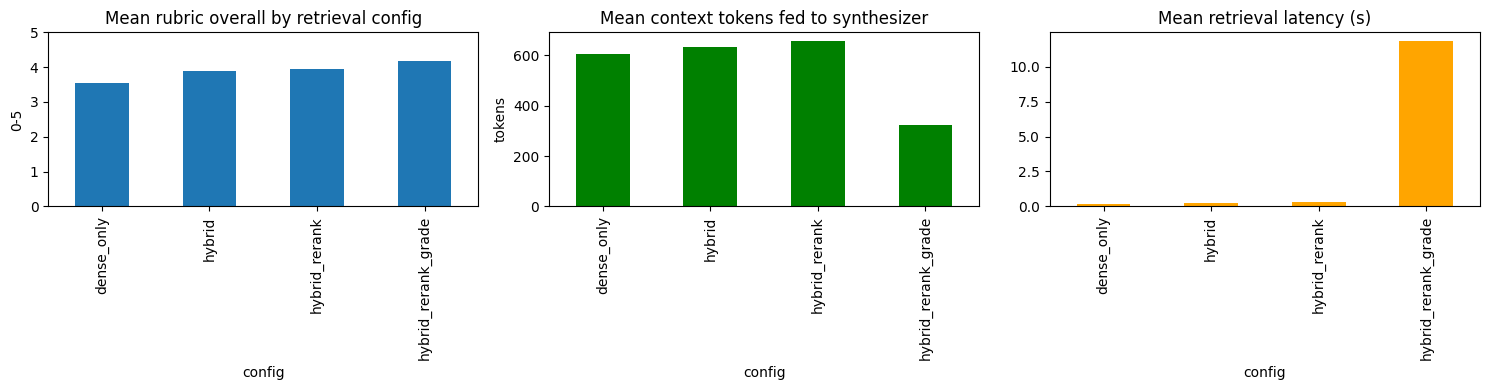

In [6]:
summary = (
    ablation.groupby("config")
    .agg(
        recall_at_5=("recall@5", "mean"),
        rubric_overall=("rubric_overall", "mean"),
        correctness=("correctness", "mean"),
        ctx_tokens=("ctx_tokens", "mean"),
        retrieve_s=("retrieve_s", "mean"),
    )
    .round(3)
    .loc[list(CONFIGS.keys())]
)
display(summary)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
summary["rubric_overall"].plot.bar(ax=axes[0])
axes[0].set_title("Mean rubric overall by retrieval config")
axes[0].set_ylim(0, 5)
axes[0].set_ylabel("0-5")
summary["ctx_tokens"].plot.bar(ax=axes[1], color="green")
axes[1].set_title("Mean context tokens fed to synthesizer")
axes[1].set_ylabel("tokens")
summary["retrieve_s"].plot.bar(ax=axes[2], color="orange")
axes[2].set_title("Mean retrieval latency (s)")
fig.tight_layout()

### Reading the ablation

| Config | recall@5 | overall | ctx_tokens | retrieve_s |
|---|---:|---:|---:|---:|
| `dense_only` | 0.83 | 3.55 | 606 | 0.16 |
| `hybrid` | 0.83 | 3.89 | 632 | 0.22 |
| `hybrid_rerank` | **1.00** | 3.94 | 658 | 0.30 |
| `hybrid_rerank_grade` | 0.67 | **4.18** | **322** | **11.85** |

Quality climbs monotonically along the pipeline (+0.63 overall). Reranking is the **recall hero** (0.83 → 1.00, doing exactly its job); grading is the **correctness hero** but actually *drops* recall (1.00 → 0.67) because it sometimes tosses chunks that would have helped — yet `correctness` still rises because the synth gets less noise. That's the CRAG paradox: lower recall, higher answer quality. Grading also roughly **halves context tokens** (658 → 322) — cheaper and better — but at **~40× the latency** (0.30s → 11.85s) because every chunk needs its own LLM call. The fifth notebook fires grading only when gap-analysis flags weak evidence, for exactly this reason.

### Where the means hide the story

| Pattern | Example | Reading |
|---|---|---|
| **Each step helps** | `cross_05`: dense=4.0 → hybrid=3.3 → rerank=4.2 → grade=4.6 | Textbook case the means describe. |
| **Reranking *hurts*** | `cross_07`: dense=3.3 → hybrid=4.8 → **rerank=2.3** → grade=2.8 | Cross-encoder demoted a chunk hybrid had surfaced. Not all reranking is monotonic. |
| **Grading rescues with tiny context** | `hotpot_00`: dense=2.0 → grade=5.0 with **32 tokens** | Brutal pruning, perfect answer — opposite of "more context = better." |
| **Nothing fixes missing-from-corpus** | `single_b1`: every config 2.0–2.8 | If the chunk isn't in the corpus, no retrieval trick helps. |

**How this stacks with the second notebook.** Decomposition added +1.0 there; this notebook adds +0.6. The two are orthogonal — decomposition fans *what you ask for*, this notebook improves *what comes back per query*. Stacking them is the fifth notebook's adaptive workflow. Practical rules: **hybrid is free** (~zero latency, +0.34); **reranking is cheap** with small variance penalty (+0.05); **grading is expensive** (+0.24 overall, halves context, but +11s/query) — use it conditionally.

## Multi-model: does the *grader* matter?

The grader is itself an LLM. If we swap it across three OpenRouter models and re-run the `hybrid_rerank_grade` config, do we see different chunks getting kept? This previews the LLM-as-judge sensitivity story we'll revisit in Week 3.

In [11]:
GRADER_MODELS = [
    "openai/gpt-5.4-nano",
    "anthropic/claude-opus-4.7",
    "x-ai/grok-4.1-fast",
]

graded_compare = []
sample_q = next(q for q in gold if q.id == "cross_05")
pool_for_compare = HybridRetriever(chroma, bm25, k=12).search(sample_q.question)

for grader_slug in GRADER_MODELS:
    grader_llm = get_llm(grader_slug)
    keeps = []
    skipped = False
    try:
        for d in pool_for_compare:
            g = grade_chunk(sample_q.question, d.page_content, judge_llm=grader_llm)
            if g.relevant:
                keeps.append(d)
    except Exception as exc:
        skipped = True
        graded_compare.append({
            "grader": grader_slug,
            "kept": None,
            "kept_titles": [f"SKIPPED: {type(exc).__name__}: {str(exc)[:80]}"],
        })
        continue
    graded_compare.append({
        "grader": grader_slug,
        "kept": len(keeps),
        "kept_titles": [d.metadata.get("title", "")[:40] for d in keeps[:5]],
    })

pd.DataFrame(graded_compare)

,grader,kept,kept_titles
0,openai/gpt-5.4-nano,3,"[Reinforcement learning from human feedba, Rei..."
1,anthropic/claude-opus-4.7,4,"[Reinforcement learning from human feedba, Rei..."
2,x-ai/grok-4.1-fast,6,"[Reinforcement learning from human feedba, Rei..."


### What this tells us about the grader

Same 12-chunk pool, same question, three graders, three different keep-counts:

| Grader | Kept |
|---|---|
| `openai/gpt-5.4-nano` | 3 |
| `anthropic/claude-opus-4.7` | 4 |
| `x-ai/grok-4.1-fast` | 6 |

A **2× spread** from a single design choice. The grader is a *strictness knob*, not a constant: stricter = cleaner context but more risk of dropping the right chunk; looser = more recall, more noise. The pragmatic rule: **use the grader you'd trust to *answer* the question** — a grader weaker than your synth tosses chunks the synth could have used; a grader much stronger is wasted compute. Match them, or sweep like this on your corpus to find the cheapest grader that keeps the right chunks.